In [1]:
import os
import ray
import datetime
import json
import torch
import mlflow
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from dynaconf import Dynaconf
from ray.rllib.models import ModelCatalog
from ray.rllib.algorithms.dqn import DQN
from ray.tune.registry import register_env
from mlflow.exceptions import MlflowException
from func_timeout import FunctionTimedOut
from botocore.exceptions import ConnectionClosedError
from utils import check_path, convert_np_arrays, env_creator, flatten_dict, display_feature_map_info

In [2]:
# Init Ray
ray.init(
    num_cpus=8,
    num_gpus=1,
    include_dashboard=True,
    object_store_memory= 32 * 1000**3,
    _system_config={"maximum_gcs_destroyed_actor_cached_count": 200},
    _temp_dir='C:/Users/seven/Documents/Ray/ray_%s' % int(datetime.datetime.now().timestamp())
)

2025-01-03 13:12:51,340	INFO worker.py:1664 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


Python version:,3.9.21
Ray version:,2.8.0
Dashboard:,http://127.0.0.1:8265


In [3]:
# Config path
env_name = "UAV_RoadNetwork"
run_name = "DDQN Classic %s" % (datetime.datetime.strftime(datetime.datetime.now(), "%Y%m%d"))
print(run_name)

# Config path
log_path = "/home/seventheli/data/logging/uav/"
checkpoint_path = "/home/seventheli/data/checkpoints/uav/"
setting = Dynaconf(envvar_prefix="DYNACONF", settings_files="./ddqn.yml")

# Set hyper parameters
hyper_parameters = setting.hyper_parameters.to_dict()
print("log path: %s \ncheck_path: %s" % (log_path, checkpoint_path))

# Seed 
# seed_value = 100
# np.random.seed(seed_value)
# torch.manual_seed(seed_value)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed(seed_value)
# hyper_parameters["seed"] = seed_value

DDQN Classic 20250103
log path: /home/seventheli/data/logging/uav/ 
check_path: /home/seventheli/data/checkpoints/uav/


In [4]:
# Set mlflow
mlflow.set_tracking_uri("http://127.0.0.1:9999")
mlflow.set_experiment(experiment_name=env_name)
mlflow_client = mlflow.tracking.MlflowClient()

In [5]:
# Check path available
check_path(log_path)
log_path = os.path.join(log_path, run_name)
check_path(log_path)
check_path(checkpoint_path)
checkpoint_path = os.path.join(checkpoint_path, run_name)
check_path(checkpoint_path)

In [6]:
# for_pred = "./reload/"
# run_id = "3fb8fd0c93d44fb79de58b9858f3e617"
# artifacts = mlflow_client.list_artifacts(run_id)
# for each in artifacts:
#     if each.path == "model_files":
#         mlflow_client.download_artifacts(run_id=run_id, path=each.path, dst_path=for_pred)

# with open('./reload/model_files/torch_checkpoint.pkl', 'rb') as f:
#     policy_weights = torch.load(f).original_model.state_dict()
#     policy_weights = {k: torch.from_numpy(v) if isinstance(v, np.ndarray) else v
#                       for k, v in policy_weights.items()}
#     policy_weights = {k: v.to("cpu")  for k, v in policy_weights.items()}

In [7]:
hyper_parameters["env_config"] =  {
    "id": "RoadNetworkAndMap",
    "agent_view_size": 3,
    "battery": 200,
    "camera":100,
    "max_steps": 500,
    "port": 7575,
    "size": 100,
    "render_mode": "rgb_array",
    "render_map_size": 100,
    "render_rate": 1,
    "agent_size": 3,
}

In [8]:
register_env(env_name, env_creator)

env = env_creator(hyper_parameters["env_config"])
env.reset()
obs, reward, terminated, truncated, info = env.step(0)
print(env.action_space, env.observation_space)

Discrete(7) Box(0, 255, (70002,), uint8)


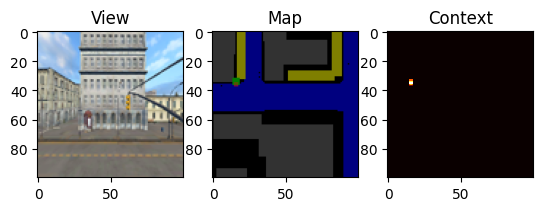

In [9]:
plt.subplot(1, 3, 1)
plt.imshow(obs[:30000].reshape(100, 100, 3))
plt.title("View")
plt.subplot(1, 3, 2)
plt.imshow(obs[30000:70000].reshape(100, 100, 4)[:, :, 0:3])
plt.title("Map")
plt.subplot(1, 3, 3)
plt.imshow(obs[30000:70000].reshape(100, 100, 4)[:, :, 3], cmap='hot', interpolation='nearest')
plt.title("Context")
plt.show()
env.close()

In [10]:
# Load Model
from model.image_decode_value_attention import AttentionCNN, WrappedModel

hyper_parameters["hiddens"] = [256, 256, 128, 64]
model_name = "AttentionCNN"
ModelCatalog.register_custom_model(model_name, AttentionCNN)
hyper_parameters["model"] = {
    "custom_model": model_name,
    "no_final_linear": True,
    "fcnet_hiddens": hyper_parameters["hiddens"] + [512],
    "custom_model_config": {
        "map_size": 100,
        "view_size": 100,
        "dueling_activation": "relu",
    }
}

In [11]:
# Set Replay Buffer
replay_buffer_config = {
    **hyper_parameters["replay_buffer_config"],
    "replay_buffer_shards_colocated_with_driver": True,
    "rollout_fragment_length": hyper_parameters["rollout_fragment_length"],
    "capacity": 200000
}
hyper_parameters["replay_buffer_config"] = replay_buffer_config

In [ ]:
trainer = DQN(config=hyper_parameters, env=env_name)

2025-01-03 13:19:29,140	WARNING deprecation.py:50 -- DeprecationWarning: `rllib/algorithms/simple_q/` has been deprecated. Use `rllib_contrib/simple_q/` instead. This will raise an error in the future!
2025-01-03 13:19:29,140	WARNING deprecation.py:50 -- DeprecationWarning: `algo = Algorithm(env='UAV_RoadNetwork', ...)` has been deprecated. Use `algo = AlgorithmConfig().environment('UAV_RoadNetwork').build()` instead. This will raise an error in the future!
C:\Users\seven\miniconda3\envs\drone\lib\site-packages\ray\rllib\algorithms\algorithm.py:484: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
C:\Users\seven\miniconda3\envs\drone\lib\site-packages\ray\tune\logger\unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in futu

In [13]:
model = trainer.get_policy().model

In [14]:
q_value, state = model.forward({"obs": torch.stack([torch.Tensor(obs)]).to("cuda")}, _, _)
advantage = model.advantage_module(q_value)
value = model.value_module(q_value)
print(advantage.to("cpu").detach().numpy()[0], value.to("cpu").detach().numpy()[0])

[-0.03133774 -1.1579478   0.22642422  1.6112827   0.57859206 -0.9745269
  0.35102487] [-0.7420442]


In [15]:
# filtered_dict = {key: value for key, value in policy_weights.items() if 'map_layer' in key}
# filtered_dict = {key.replace('map_layers.', ''): value for key, value in filtered_dict.items()}
# model.map_layers.load_state_dict(filtered_dict)

In [16]:
keys_to_extract_sam = {"episode_reward_max", "episode_reward_min", "episode_reward_mean"}
keys_to_extract_sta = {"num_agent_steps_sampled", "num_agent_steps_trained"}

In [17]:
mlflow_run = mlflow.start_run(run_name=run_name, tags={"mlflow.user": "Local"})
# Log parameters
mlflow.log_params(hyper_parameters["replay_buffer_config"])
to_log = ['double_q', 'dueling', 'lr', 'n_step', 'num_steps_sampled_before_learning_starts',
          'rollout_fragment_length', 'target_network_update_freq', 'train_batch_size', 'min_sample_timesteps_per_iteration']
mlflow.log_params(
    {key: hyper_parameters[key] for key in to_log})

In [18]:
model_uri = "runs:/%s/model_name" % mlflow_run.info.run_id

In [ ]:
for i in tqdm(range(0, setting.log.max_run), ascii=True):
    result = trainer.train()
    time_used = result["time_total_s"]
    try:
        sampler = result.get("sampler_results", {}).copy()
        eva = result.get("evaluation", {}).copy()
        info = result.get("info", {}).copy()
        sam = {key: sampler[key] for key in keys_to_extract_sam if key in sampler}
        sta = {key: info[key] for key in keys_to_extract_sta if key in info}
        buf = flatten_dict(trainer.local_replay_buffer.stats())
        buf["est_size_gb"] = buf["est_size_bytes"] /1e9
        result['buffer'] = buf
        time_usage = info.get("learner", {}).get("time_usage", {})
        if eva:
            eva = {"eval_" + key: eva[key] for key in keys_to_extract_sam if key in eva}
        mlflow.log_metrics({**sam, **sta, **buf, **time_usage, **eva, **{"time_total": time_used}}, step=result["episodes_total"])
        if i > 10 and i % (setting.log.log * 5) == 0:
            tqdm.write("episode %d ; " % result["episodes_total"] + " ".join(["%s : %f8" % (i, j) for i, j in sam.items()]))
        if i > 10 and i % (setting.log.log * 50) == 0:
            # Save Model
            trainer.save_checkpoint(checkpoint_path)
            model_to_save = trainer.get_policy().model
            model_to_save = WrappedModel(model_to_save)
            with open(checkpoint_path + "/torch_checkpoint.pkl", "wb") as f:
                torch.save(model_to_save, f)
            # mlflow.pytorch.log_model(trainer.get_policy().model, run_name)
            # mlflow.register_model(model_uri, run_name, tags={
            #     "episode" : result["episodes_total"],
            #     "reward": sam["episode_reward_mean"],
            # })
    except FunctionTimedOut:
        tqdm.write("logging failed")
    except MlflowException:
        tqdm.write("logging failed")
    except ConnectionClosedError:
        tqdm.write("logging failed")
        
    # Save JSON
    with open(os.path.join(log_path, str(i) + ".json"), "w") as f:
        result["config"] = None
        json.dump(convert_np_arrays(result), f)
    if time_used >= setting.log.max_time:
        break

  0%|          | 0/50000 [00:00<?, ?it/s]

2025-01-01 03:01:59,639	WARNING replay_buffer.py:61 -- Estimated max memory usage for replay buffer is 28.0104 GB (200000.0 batches of size 1, 140052 bytes each), available system memory is 137.142362112 GB
2025-01-01 03:01:59,639	WARNING multi_agent_prioritized_replay_buffer.py:215 -- Adding batches with column `weights` to this buffer while providing weights as a call argument to the add method results in the column being overwritten.
2025-01-01 04:03:57,758	WARNING deprecation.py:50 -- DeprecationWarning: `ray.rllib.execution.train_ops.multi_gpu_train_one_step` has been deprecated. This will raise an error in the future!


episode 1091 ; episode_reward_min : -0.2120008 episode_reward_mean : -0.0019008 episode_reward_max : 1.0604008
episode 1451 ; episode_reward_min : -0.2090008 episode_reward_mean : -0.0170268 episode_reward_max : 1.0612008
episode 1784 ; episode_reward_min : -0.2110008 episode_reward_mean : 0.0475888 episode_reward_max : 1.0484008
episode 2097 ; episode_reward_min : -0.2100008 episode_reward_mean : -0.0421408 episode_reward_max : 1.0568008
episode 2417 ; episode_reward_min : -0.2120008 episode_reward_mean : 0.0129488 episode_reward_max : 1.1048008
episode 2719 ; episode_reward_min : -0.2080008 episode_reward_mean : 0.0220868 episode_reward_max : 1.0944008
episode 3023 ; episode_reward_min : -0.2110008 episode_reward_mean : -0.0315168 episode_reward_max : 1.0828008
episode 3318 ; episode_reward_min : -0.2140008 episode_reward_mean : -0.0304908 episode_reward_max : 1.0688008
episode 3592 ; episode_reward_min : -0.2160008 episode_reward_mean : -0.0133088 episode_reward_max : 1.0608008
epis

In [ ]:
trainer.save_checkpoint(checkpoint_path)
model_to_save = trainer.get_policy().model
model_to_save = WrappedModel(model_to_save)
mlflow.pytorch.log_model(model_to_save, run_name)
with open(checkpoint_path + "/torch_checkpoint.pkl", "wb") as f:
    torch.save(model_to_save, f)
mlflow.register_model(model_uri, run_name, tags={
    "episode" : result["episodes_total"],
    "reward": sam["episode_reward_mean"],
})

In [ ]:
mlflow.end_run()